<a href="https://colab.research.google.com/github/srinivas340/ml_practice/blob/main/hand_written_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torchvision.datasets import MNIST

In [2]:
#Download training dataset
dataset=MNIST(root='data/',download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.27MB/s]


when above statement exicute for the first time it dowloads the the data for next exicution its skipped as data is already downloaded

In [3]:
len(dataset)

60000

the dataset has 60000 images which can be used to train the model. there is also an additional test set of 10000 images which can be created by passing ***train=False***  to the MNIST class

In [4]:
test_dataset=MNIST(root='data/',train=False)
len(test_dataset)

10000

In [5]:
dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

Label: 5


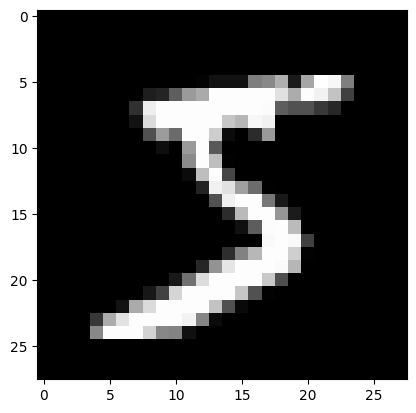

In [7]:
image, label=dataset[0]
plt.imshow(image,cmap='gray')
print('Label:',label)

Label: 5


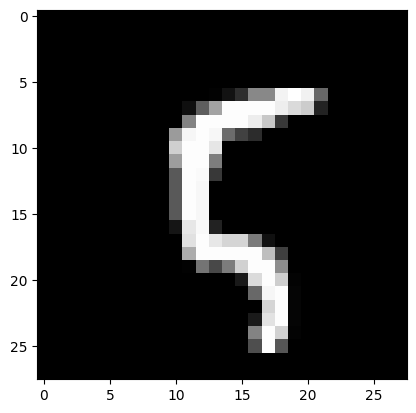

In [8]:
image, label=dataset[100]
plt.imshow(image,cmap='gray')
print('Label:',label)

it's evident that these images are quite small in size, and quict small in size and recognizing the digits can sometimes be hard even for human eye.

while it's useful to look at these images, there's just one problem here:


pytorch doesn't know how to work with images. we need to convert the image into tensors.

we can do this by specifying a transform while creating our dataset.

In [9]:
import torchvision.transforms as transforms

pytorch dataset allows us to specify one or more transformation functions which are applied to the images as they are loaded ***torchvision.transforms*** contain many such predefined function and we will use ***ToTensor*** transform to convert images into pytorch tensors.

In [10]:
#MNIST dataset(images and labels)
dataset=MNIST(root='data/',train=True,transform=transforms.ToTensor())

In [11]:
img_tensor, label = dataset[0]
print(img_tensor.shape,label)

torch.Size([1, 28, 28]) 5


The image is now converted to a 1x28x28 tensor.

The first dimension is used to keep track of the colour channels.

since images in the MNIST dataset are grayscale, there's just one channel.

 Other datasets with colour, in which case there are 3 channels:red , green and blue(RGB).


let's look at some sample values inside the tensor:


In [12]:
print(img_tensor[0,10:15,10:15])
print(torch.min(img_tensor),torch.max(img_tensor))

tensor([[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
        [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
        [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
        [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
        [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]])
tensor(0.) tensor(1.)


The values range from o to 1 with 0 representing black, white and the values in between different shades of grey.

we also plot the tensor as an image using   ***plt.imshow***

Label: 5


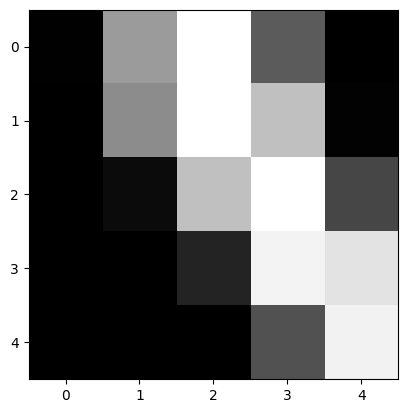

In [13]:
#PLot the image by passing in the 28x28 matrix
plt.imshow(img_tensor[0,10:15,10:15],cmap='gray')
print('Label:',label)

# Training and Validation Datasets


while building real world machine learning models , it is quite common to split the dataset into 3 parts:

1.**Training set** - used to train the model i.e compute the loss and adjust the weights of the model using gradient descent.

2.**Validation set** - used to evaluate the model while training, adjusting hyperparameters(learning rate etc) and pick the best version of the model.

3.**test set** - used to compare the different momdel or different types of modeling approchs and report the final accuracy of the model.





in MNIST dataset, there are 60,000 training images and 10,000 test images.

since there's is no predefined validation set, we must manually split the 60,000 images into training and validation datasets

In [14]:
import numpy as np
def split_indices(n, val_pct):
  #Determine size of validation set
  n_val=int(val_pct*n)
  #Create random permutation of 0 to n-1
  idxs=np.random.permutation(n)
  #Pick first n_val indices for validation set
  return idxs[n_val:],idxs[:n_val]

In [15]:
train_indices,val_indices=split_indices(len(dataset),val_pct=0.2)

In [16]:
print(len(train_indices),len(val_indices))
print('Sample val indices: ',val_indices[:20])

48000 12000
Sample val indices:  [19172 38288 38342 22692 42564 55239 11305 34645 34243 48009 22203  4568
 28889 32700 38726 27134 18433 37234  5930  6151]


we have randomly shuffuled the indices and selected a small portion (20%) to serve as the validation set

we can now creat pytorch data loader for each of these using a ***SubsetRandomSampler***, which samples elements randomly from a given list of indices,while greating batchs of data

In [17]:
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

In [18]:
batch_size=100

#Training sampler and data loader
train_sampler = SubsetRandomSampler(train_indices)
train_loader = DataLoader(dataset,batch_size,sampler=train_sampler)

#Validation sampler and data loader
val_sampler = SubsetRandomSampler(val_indices)
val_loader = DataLoader(dataset,batch_size,sampler=val_sampler)

In [19]:
# Load the test dataset with the ToTensor transform
test_dataset = MNIST(root='data/', train=False, transform=transforms.ToTensor(), download=True)

# Create a test data loader
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Model


now that we have prepared our data loaders,we can define our model.

1.A **logistic regression** model is almost identical to alinear regression model i.e there are weights and bias matrix and the output is obtained using simple matix operations(pred = x@ w.t()+b)

2.just as we did with linear regression we can use (nn.Linear)  to creat the model instead of defining and initializing the matrix manually.

3.Since (nn.Linear) expects the each training example to be a vector

4.the output for each image is a vector of size 10, with each element of the vector signifying the probability a particulay target lable (0 to 9). the predicted lable for an image is simply the one with the highest probability.

In [20]:
import torch.nn as nn

input_size=28*28
num_classes=10

#Logistic regression model
model=nn.Linear(input_size,num_classes)

In [21]:
print(model.weight.shape)
model.weight

torch.Size([10, 784])


Parameter containing:
tensor([[-0.0184, -0.0186, -0.0350,  ...,  0.0309, -0.0262,  0.0137],
        [ 0.0073, -0.0076, -0.0052,  ...,  0.0152, -0.0326,  0.0316],
        [ 0.0154, -0.0273,  0.0218,  ...,  0.0229, -0.0347,  0.0071],
        ...,
        [-0.0252,  0.0234, -0.0321,  ..., -0.0307,  0.0165, -0.0272],
        [-0.0026,  0.0287,  0.0293,  ...,  0.0322,  0.0286, -0.0339],
        [ 0.0119,  0.0189, -0.0082,  ...,  0.0280, -0.0186,  0.0056]],
       requires_grad=True)

In [22]:
print(model.bias.shape)
model.bias

torch.Size([10])


Parameter containing:
tensor([-0.0137,  0.0042,  0.0262, -0.0122, -0.0167,  0.0053, -0.0323, -0.0066,
        -0.0157, -0.0064], requires_grad=True)

Although there are a total of 7850 parameters here, conceptually nothing has changed so far. Let's try and generate some outputs using our model. we'll take the first batch of 100 images from our dataset, and pass them into our model.

In [23]:
for images, labels in train_loader:
  print(labels)
  print(images.shape)
  images = images.reshape(images.shape[0], -1) # Flatten images
  outputs=model(images)
  break

tensor([0, 9, 9, 2, 8, 4, 5, 7, 5, 1, 5, 9, 4, 1, 7, 6, 8, 4, 3, 0, 4, 5, 5, 8,
        2, 0, 9, 7, 4, 8, 4, 1, 5, 6, 0, 3, 2, 1, 3, 4, 7, 1, 4, 9, 2, 0, 6, 9,
        9, 6, 8, 0, 9, 4, 8, 6, 7, 4, 2, 0, 6, 1, 1, 3, 5, 4, 7, 5, 3, 7, 2, 9,
        1, 7, 6, 0, 1, 0, 0, 7, 7, 3, 0, 8, 1, 8, 8, 5, 4, 2, 0, 4, 3, 3, 3, 3,
        9, 6, 2, 1])
torch.Size([100, 1, 28, 28])


To include this additional functionalty within our model,we need to define a custom model, by extending the **nn.Module** class from Pytorch

In [24]:
class MinistModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(input_size, num_classes)

  def forward(self, xb):
    xb=xb.reshape(-1,784)
    out=self.linear(xb)
    return out
model=MinistModel()

In [25]:
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[-0.0082, -0.0254,  0.0174,  ...,  0.0024,  0.0094,  0.0103],
         [-0.0039,  0.0285, -0.0008,  ..., -0.0257,  0.0351, -0.0242],
         [ 0.0302,  0.0208,  0.0151,  ..., -0.0068,  0.0161, -0.0026],
         ...,
         [-0.0157, -0.0107, -0.0140,  ...,  0.0116,  0.0098,  0.0262],
         [ 0.0093,  0.0085,  0.0026,  ...,  0.0278,  0.0329,  0.0334],
         [ 0.0329, -0.0097,  0.0110,  ...,  0.0058, -0.0267, -0.0290]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0285, -0.0187, -0.0261,  0.0048,  0.0184, -0.0199, -0.0337,  0.0333,
          0.0251, -0.0067], requires_grad=True)]

Our new custom model can be used in the exact same way as before. lets see if its works

In [26]:
for images, labels in train_loader:
  outputs=model(images)
  break

print('outputs.shape : ',outputs.shape)
print('Sample outputs :\n', outputs[:2].data)

outputs.shape :  torch.Size([100, 10])
Sample outputs :
 tensor([[ 8.6878e-02,  6.7516e-03,  1.5649e-02, -1.3311e-01,  6.5654e-02,
          1.0248e-01,  2.5314e-04, -5.7919e-02, -6.6304e-02, -1.2108e-02],
        [ 4.6373e-01,  4.0070e-01, -3.9436e-01,  4.9017e-01,  1.9446e-02,
          1.0664e-01, -1.8462e-01,  9.0723e-02, -1.5093e-01, -7.6506e-01]])


The outputs for each image are 10 numbers. Each number indicates the probability of the image belonging to a particular class (0 to 9). Higher the number, higher the probability of the image belonging to that class. Since the probabilities are raw and not normalized, we'll use `softmax` to normalize them and `argmax` to get the predicted label.

In [27]:
import torch.nn.functional as F

# Re-extract a batch to ensure 'outputs' and 'labels' are defined
# This assumes 'train_loader' and 'model' are already defined from previous cells.
for images, labels in train_loader:
    outputs = model(images.reshape(images.shape[0], -1)) # Flatten images for model
    break

# Apply softmax to the outputs to get probabilities
probs = F.softmax(outputs, dim=1)

# Take the highest probability for each output
max_probs, preds = torch.max(probs, dim=1)

print('Probabilities for the first 2 images:\n', probs[:2].data)
print('Predicted labels for the first 2 images:', preds[:2].data)
print('Actual labels for the first 2 images:', labels[:2].data)

Probabilities for the first 2 images:
 tensor([[0.1244, 0.1070, 0.1004, 0.1000, 0.0913, 0.1088, 0.0818, 0.0924, 0.0886,
         0.1053],
        [0.1161, 0.0949, 0.1022, 0.1025, 0.1073, 0.1213, 0.1125, 0.0786, 0.0894,
         0.0752]])
Predicted labels for the first 2 images: tensor([0, 5])
Actual labels for the first 2 images: tensor([4, 5])


Let's also define a helper function to calculate the accuracy of the model.

In [28]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

The model has not been trained yet, so the accuracy will likely be very low.

In [29]:
print(accuracy(outputs, labels))

tensor(0.1100)


## Training the model

Now we can define the loss function and optimizer for training.

In [30]:
import torch
import torch.nn.functional as F

loss_fn = F.cross_entropy
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

We'll also define an evaluation function to measure the model's performance on the validation set after each epoch.

In [31]:
import torch

def evaluate(model, val_loader):
    outputs_list = []
    labels_list = []
    for images, labels_batch in val_loader:
        images_flat = images.reshape(images.shape[0], -1) # Flatten images for model
        outputs_list.append(model(images_flat))
        labels_list.append(labels_batch)
    all_outputs = torch.cat(outputs_list)
    all_labels = torch.cat(labels_list)
    return accuracy(all_outputs, all_labels)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = [] # For recording epoch-wise results

    for epoch in range(epochs):
        # Training Phase
        for images, labels in train_loader:
            images = images.reshape(images.shape[0], -1) # Flatten images
            out = model(images)                 # Generate predictions
            loss = loss_fn(out, labels) # Calculate loss
            loss.backward()                     # Compute gradients
            optimizer.step()                    # Update parameters
            optimizer.zero_grad()               # Reset gradients

        # Validation phase
        result = evaluate(model, val_loader)
        history.append(result)
        print(f'Epoch [{epoch+1}/{epochs}], Validation Accuracy: {result:.4f}')
    return history

Before training, let's see the initial accuracy on the validation set.

In [32]:
initial_accuracy = evaluate(model, val_loader)
print(f'Initial Validation Accuracy: {initial_accuracy:.4f}')

Initial Validation Accuracy: 0.1143


Now, let's train the model for 5 epochs.

In [33]:
history = fit(5, 0.001, model, train_loader, val_loader)


Epoch [1/5], Validation Accuracy: 0.6837
Epoch [2/5], Validation Accuracy: 0.7557
Epoch [3/5], Validation Accuracy: 0.7808
Epoch [4/5], Validation Accuracy: 0.7962
Epoch [5/5], Validation Accuracy: 0.8063


Let's continue training the model for more epochs to try and achieve higher accuracy.

In [34]:
print(f'Continuing training for 15 more epochs (total 20 epochs).')
new_history = fit(15, 0.001, model, train_loader, val_loader)
history.extend(new_history)
print('\nFull training history (validation accuracy per epoch):', history)

Continuing training for 15 more epochs (total 20 epochs).
Epoch [1/15], Validation Accuracy: 0.8150
Epoch [2/15], Validation Accuracy: 0.8230
Epoch [3/15], Validation Accuracy: 0.8278
Epoch [4/15], Validation Accuracy: 0.8313
Epoch [5/15], Validation Accuracy: 0.8349
Epoch [6/15], Validation Accuracy: 0.8379
Epoch [7/15], Validation Accuracy: 0.8413
Epoch [8/15], Validation Accuracy: 0.8444
Epoch [9/15], Validation Accuracy: 0.8469
Epoch [10/15], Validation Accuracy: 0.8493
Epoch [11/15], Validation Accuracy: 0.8518
Epoch [12/15], Validation Accuracy: 0.8529
Epoch [13/15], Validation Accuracy: 0.8546
Epoch [14/15], Validation Accuracy: 0.8559
Epoch [15/15], Validation Accuracy: 0.8576

Full training history (validation accuracy per epoch): [tensor(0.6837), tensor(0.7557), tensor(0.7808), tensor(0.7962), tensor(0.8063), tensor(0.8150), tensor(0.8230), tensor(0.8278), tensor(0.8313), tensor(0.8349), tensor(0.8379), tensor(0.8413), tensor(0.8444), tensor(0.8469), tensor(0.8493), tensor(0.

Now that the model has been trained for more epochs, let's re-evaluate its performance on the test set.

In [35]:
test_accuracy_after_more_epochs = evaluate(model, test_loader)
print(f'Test Accuracy after 20 epochs: {test_accuracy_after_more_epochs:.4f}')

Test Accuracy after 20 epochs: 0.8686


The model has improved, but hasn't reached 90% accuracy yet. Let's try training for more epochs with a slightly lower learning rate.

In [36]:
print(f'Continuing training for another 20 epochs (total 40 epochs) with a learning rate of 0.0005.')
new_history_lr = fit(20, 0.0005, model, train_loader, val_loader)
history.extend(new_history_lr)
print('\nFull training history (validation accuracy per epoch):', history)

Continuing training for another 20 epochs (total 40 epochs) with a learning rate of 0.0005.
Epoch [1/20], Validation Accuracy: 0.8579
Epoch [2/20], Validation Accuracy: 0.8587
Epoch [3/20], Validation Accuracy: 0.8595
Epoch [4/20], Validation Accuracy: 0.8597
Epoch [5/20], Validation Accuracy: 0.8604
Epoch [6/20], Validation Accuracy: 0.8610
Epoch [7/20], Validation Accuracy: 0.8616
Epoch [8/20], Validation Accuracy: 0.8623
Epoch [9/20], Validation Accuracy: 0.8627
Epoch [10/20], Validation Accuracy: 0.8631
Epoch [11/20], Validation Accuracy: 0.8635
Epoch [12/20], Validation Accuracy: 0.8643
Epoch [13/20], Validation Accuracy: 0.8647
Epoch [14/20], Validation Accuracy: 0.8648
Epoch [15/20], Validation Accuracy: 0.8652
Epoch [16/20], Validation Accuracy: 0.8657
Epoch [17/20], Validation Accuracy: 0.8662
Epoch [18/20], Validation Accuracy: 0.8668
Epoch [19/20], Validation Accuracy: 0.8668
Epoch [20/20], Validation Accuracy: 0.8668

Full training history (validation accuracy per epoch): [

Now, let's re-evaluate the model on the test set after further training.

In [37]:
final_test_accuracy = evaluate(model, test_loader)
print(f'Final Test Accuracy after 40 epochs: {final_test_accuracy:.4f}')

Final Test Accuracy after 40 epochs: 0.8768


The model is still showing incremental improvements. Let's continue training for more epochs to see if we can get closer to the target accuracy.

In [38]:
print(f'Continuing training for another 20 epochs (total 60 epochs) with a learning rate of 0.0005.')
new_history_more_epochs = fit(20, 0.0005, model, train_loader, val_loader)
history.extend(new_history_more_epochs)
print('\nFull training history (validation accuracy per epoch):', history)

Continuing training for another 20 epochs (total 60 epochs) with a learning rate of 0.0005.
Epoch [1/20], Validation Accuracy: 0.8670
Epoch [2/20], Validation Accuracy: 0.8677
Epoch [3/20], Validation Accuracy: 0.8683
Epoch [4/20], Validation Accuracy: 0.8683
Epoch [5/20], Validation Accuracy: 0.8687
Epoch [6/20], Validation Accuracy: 0.8697
Epoch [7/20], Validation Accuracy: 0.8700
Epoch [8/20], Validation Accuracy: 0.8703
Epoch [9/20], Validation Accuracy: 0.8704
Epoch [10/20], Validation Accuracy: 0.8704
Epoch [11/20], Validation Accuracy: 0.8708
Epoch [12/20], Validation Accuracy: 0.8708
Epoch [13/20], Validation Accuracy: 0.8709
Epoch [14/20], Validation Accuracy: 0.8712
Epoch [15/20], Validation Accuracy: 0.8712
Epoch [16/20], Validation Accuracy: 0.8715
Epoch [17/20], Validation Accuracy: 0.8720
Epoch [18/20], Validation Accuracy: 0.8723
Epoch [19/20], Validation Accuracy: 0.8726
Epoch [20/20], Validation Accuracy: 0.8733

Full training history (validation accuracy per epoch): [

After more training, let's evaluate the model on the test set one last time.

In [39]:
final_test_accuracy_60_epochs = evaluate(model, test_loader)
print(f'Final Test Accuracy after 60 epochs: {final_test_accuracy_60_epochs:.4f}')

Final Test Accuracy after 60 epochs: 0.8830


## Evaluating on the Test Set

Finally, let's evaluate the model on the `test_dataset` to see its final performance.

In [40]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data.dataloader import DataLoader
import torch

# Load the test dataset with the ToTensor transform
test_dataset = MNIST(root='data/', train=False, transform=transforms.ToTensor(), download=True)

# Create a test data loader
test_loader = DataLoader(test_dataset, batch_size=100)

# Evaluate the model on the test loader
test_accuracy = evaluate(model, test_loader)
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 0.8830
